In [25]:
import librosa
import numpy as np
import pandas as pd
import emd

In [31]:
# PACIENTE ENFERMO (URTI)
audio_path = "./Respiratory_Sound_Database\Respiratory_Sound_Database//audio_and_txt_files//101_1b1_Al_sc_Meditron.wav"
audio_sick, sr_sick = librosa.load(audio_path, sr=None)  # sr=None para mantener la tasa de muestreo original
time_sick = np.arange(len(audio_sick))/sr_sick


print(f"Duración del audio: {len(audio_sick)/sr_sick} segundos")
print(f"Tasa de muestreo: {sr_sick} Hz")

Duración del audio: 20.0 segundos
Tasa de muestreo: 44100 Hz


In [32]:
# PACIENTE SANO
audio_path = "./Respiratory_Sound_Database\Respiratory_Sound_Database//audio_and_txt_files//102_1b1_Ar_sc_Meditron.wav"
audio_healthy, sr_healthy = librosa.load(audio_path, sr=None)  # sr=None para mantener la tasa de muestreo original
time_healthy = np.arange(len(audio_healthy))/sr_healthy

print(f"Duración del audio: {len(audio_healthy)/sr_healthy} segundos")
print(f"Tasa de muestreo: {sr_healthy} Hz")

Duración del audio: 20.0 segundos
Tasa de muestreo: 44100 Hz


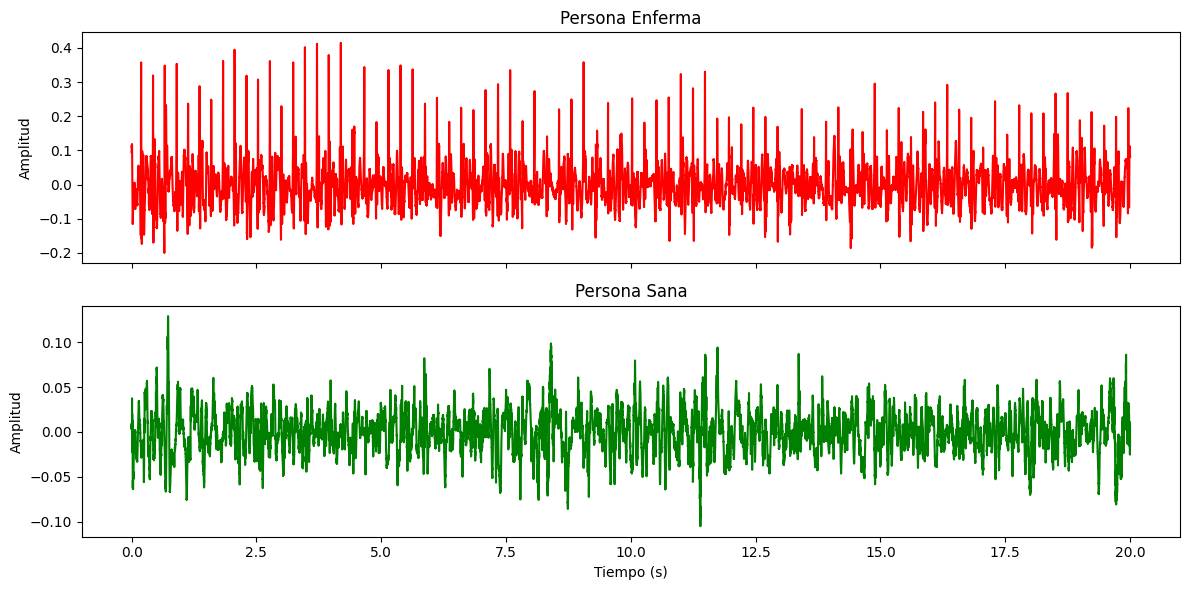

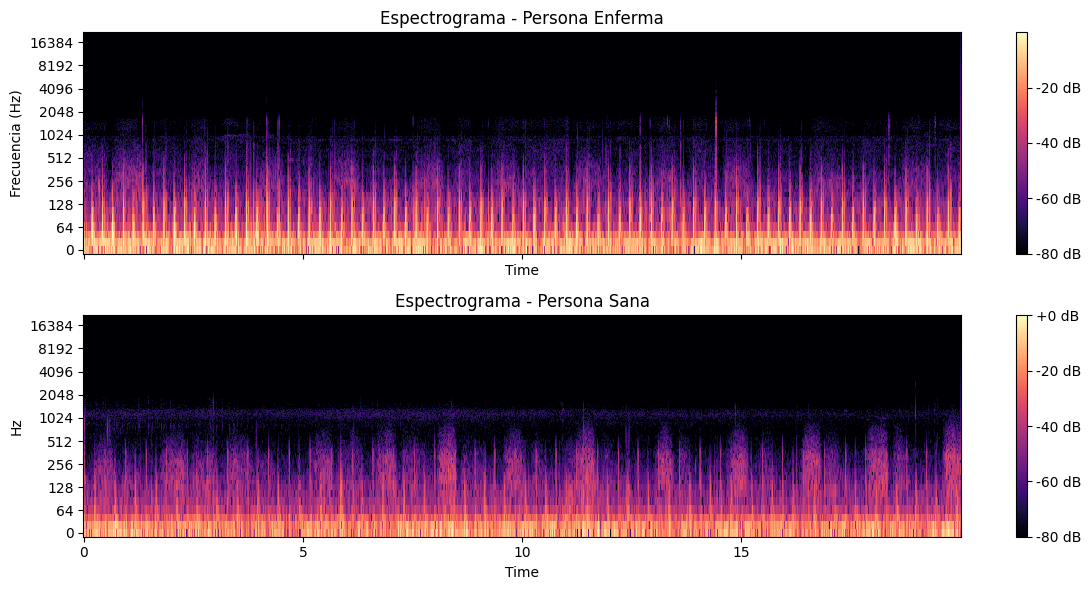

In [20]:
import matplotlib.pyplot as plt

# Graficar las formas de onda
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Gráfico de persona enferma
ax[0].plot(np.arange(len(audio_sick)) / sr_sick, audio_sick, color='red')
ax[0].set_title("Persona Enferma")
ax[0].set_ylabel("Amplitud")


# Gráfico de persona sana
ax[1].plot(np.arange(len(audio_healthy)) / sr_healthy, audio_healthy, color='green')
ax[1].set_title("Persona Sana")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Amplitud")

plt.tight_layout()  
plt.show()



# Calcular espectrogramas
D_sick = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sick)), ref=np.max)
D_healthy = librosa.amplitude_to_db(np.abs(librosa.stft(audio_healthy)), ref=np.max)

# Crear la figura con dos subgráficos
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Espectrograma para persona enferma
librosa.display.specshow(D_sick, sr=sr_sick, x_axis='time', y_axis='log', ax=ax[0])
ax[0].set_title("Espectrograma - Persona Enferma")
ax[0].set_ylabel("Frecuencia (Hz)")
fig.colorbar(librosa.display.specshow(D_sick, sr=sr_sick, x_axis='time', y_axis='log'), ax=ax[0], format='%+2.0f dB')

# Espectrograma para persona sana
librosa.display.specshow(D_healthy, sr=sr_healthy, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set_title("Espectrograma - Persona Sana")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Frecuencia (Hz)")
fig.colorbar(librosa.display.specshow(D_healthy, sr=sr_healthy, x_axis='time', y_axis='log'), ax=ax[1], format='%+2.0f dB')

plt.tight_layout()  
plt.show()

Forma de imfs: (882000, 5)


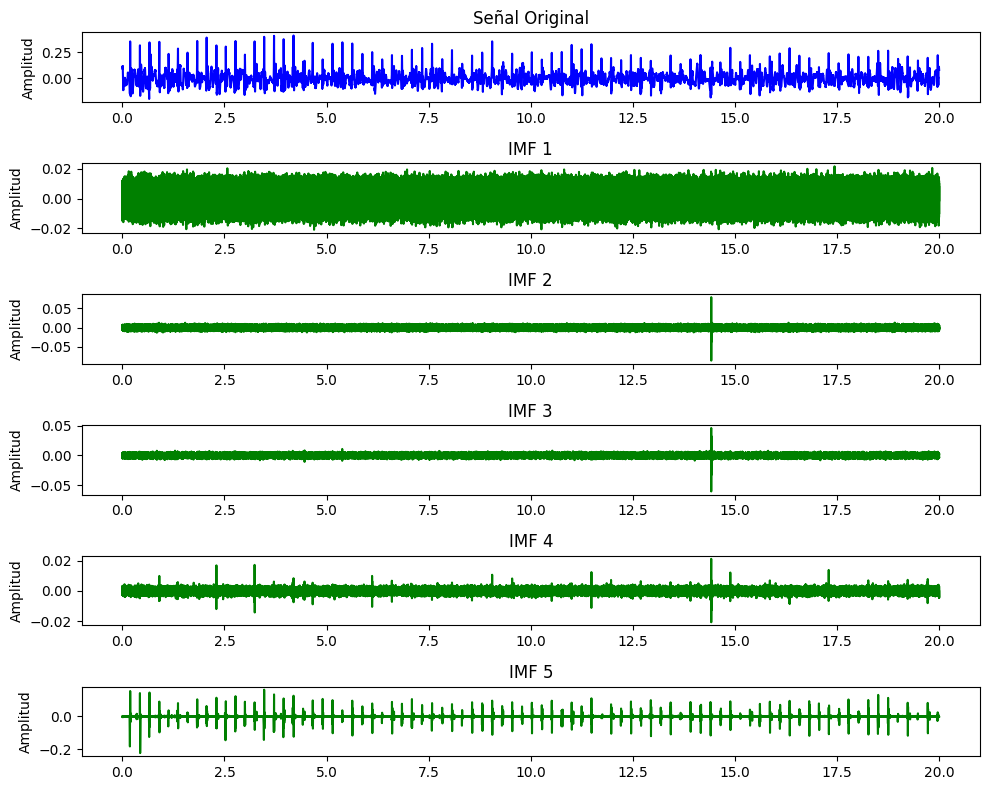

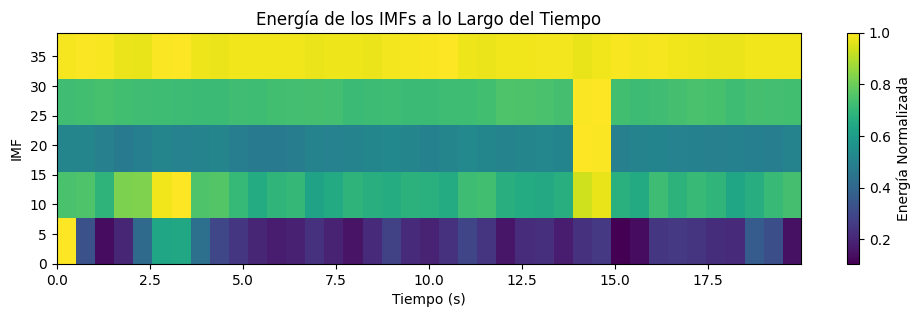

In [35]:
#PERSONA ENFERMA

# Aplicar EMD para obtener los IMFs
imfs_sick = emd.sift.ensemble_sift(audio_sick, max_imfs=5)

# Verificar la forma de los IMFs
print("Forma de imfs:", imfs_sick.shape)

# Graficar la señal original y los IMFs
plt.figure(figsize=(10, 8))
plt.subplot(imfs_sick.shape[1] + 1, 1, 1)
plt.plot(time_sick, audio_sick, 'b')
plt.title("Señal Original")
plt.ylabel("Amplitud")

for i, imf in enumerate(imfs_sick.T):
    plt.subplot(imfs_sick.shape[1] + 1, 1, i + 2)
    plt.plot(time_sick, imf, 'g')
    plt.title(f"IMF {i + 1}")
    plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

# Calcular la energía de los IMFs en ventanas de tiempo
window_size_sec = 1.0  # Ventana de 1 segundo
window_size = int(window_size_sec * sr_sick)
window_step = window_size // 2  # Superposición del 50%

energy = np.lib.stride_tricks.sliding_window_view(imfs_sick**2, window_shape=window_size, axis=0)[::window_step, :, :]
energy = np.sum(energy, axis=-1)

# Normalizar la energía
max_energies = np.max(energy, axis=0)
energy = energy / max_energies

# Graficar el mapa de calor de la energía
plt.figure(figsize=(12, 3))
plt.imshow(energy.T, aspect='auto', extent=[time_sick[0], time_sick[-1], 0, energy.shape[0]], cmap='viridis')
plt.colorbar(label="Energía Normalizada")
plt.xlabel("Tiempo (s)")
plt.ylabel("IMF")
plt.title("Energía de los IMFs a lo Largo del Tiempo")
plt.show()

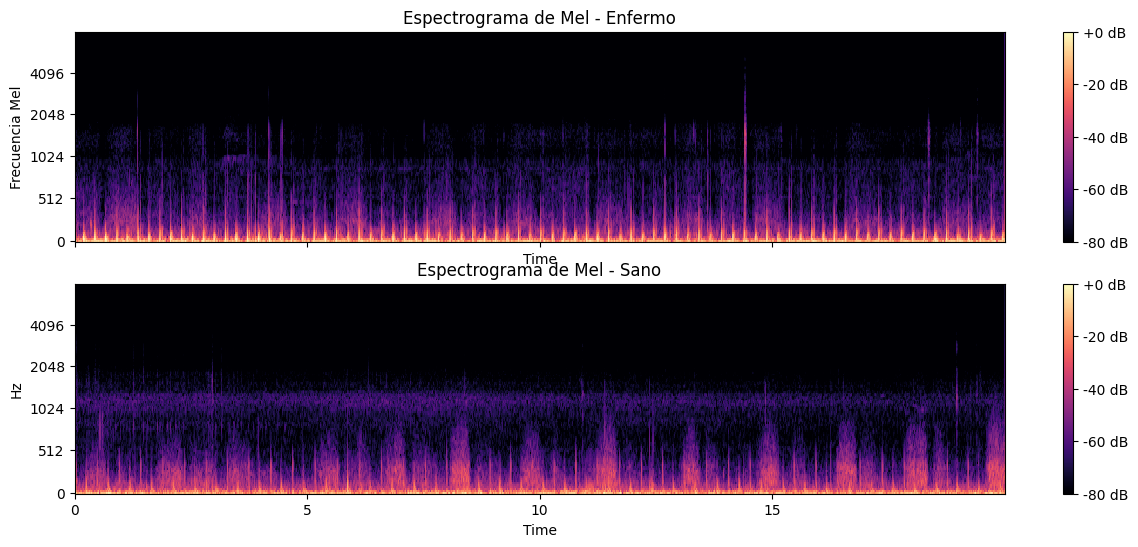

In [48]:
# Convertir a espectrograma de Mel
n_mels = 128  # Número de filtros de Mel (ajústalo según necesites)
S_sick = librosa.feature.melspectrogram(y=audio_sick, sr=sr_sick, n_mels=n_mels, fmax=8000)  # Filtrado hasta 8 kHz
S_healthy = librosa.feature.melspectrogram(y=audio_healthy, sr=sr_healthy, n_mels=n_mels, fmax=8000)  # Filtrado hasta 8 kHz

# Convertir a escala logarítmica (más similar a cómo escucha el oído humano)
S_sick_dB = librosa.power_to_db(S_sick, ref=np.max)
S_healthy_dB = librosa.power_to_db(S_healthy, ref=np.max)

# Crear la figura con dos subgráficos
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# Graficar el espectrograma de Mel de persona enferma
librosa.display.specshow(S_sick_dB, sr=sr_sick, x_axis="time", y_axis="mel", fmax=8000, ax = ax[0])
ax[0].set_title("Espectrograma de Mel - Enfermo")
ax[0].set_ylabel("Frecuencia Mel")
fig.colorbar(librosa.display.specshow(S_sick_dB, sr=sr_sick, x_axis="time", y_axis="mel", fmax=8000), ax = ax[0], format="%+2.0f dB")

# Graficar el espectrograma de Mel de persona sana
librosa.display.specshow(S_healthy_dB, sr=sr_healthy, x_axis="time", y_axis="mel", fmax=8000, ax = ax[1])
ax[1].set_title("Espectrograma de Mel - Sano")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Frecuencia Mel")
fig.colorbar(librosa.display.specshow(S_healthy_dB, sr=sr_healthy, x_axis="time", y_axis="mel", fmax=8000), ax = ax[1], format="%+2.0f dB")

plt.show()

Forma de imfs: (882000, 5)


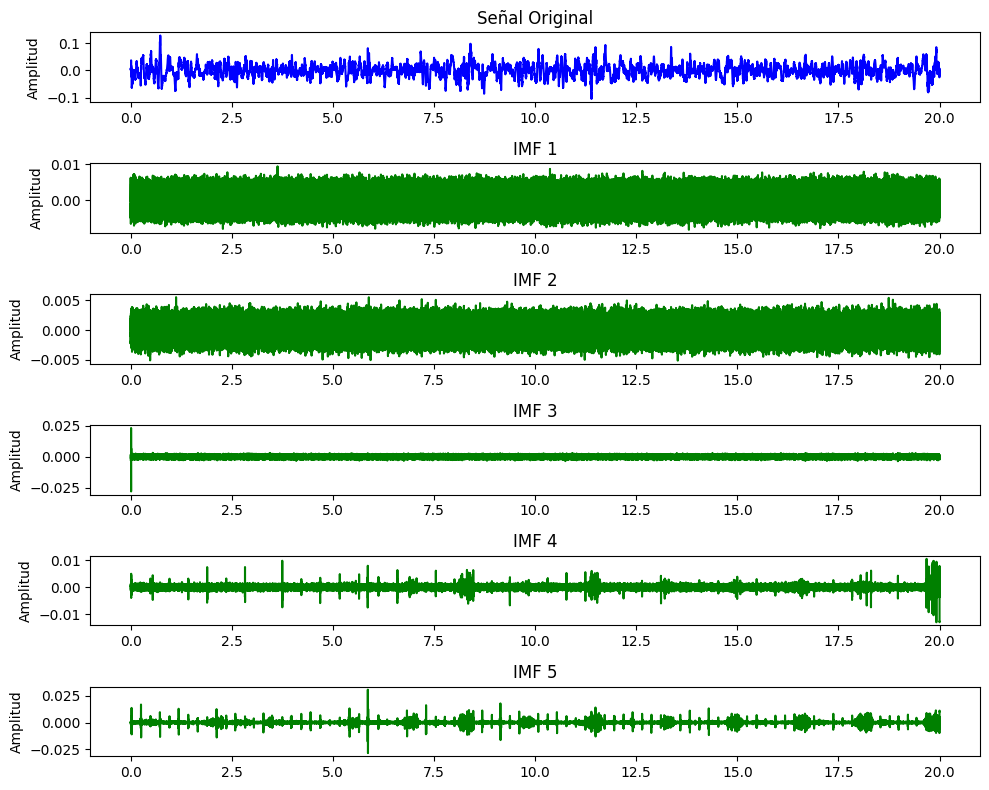

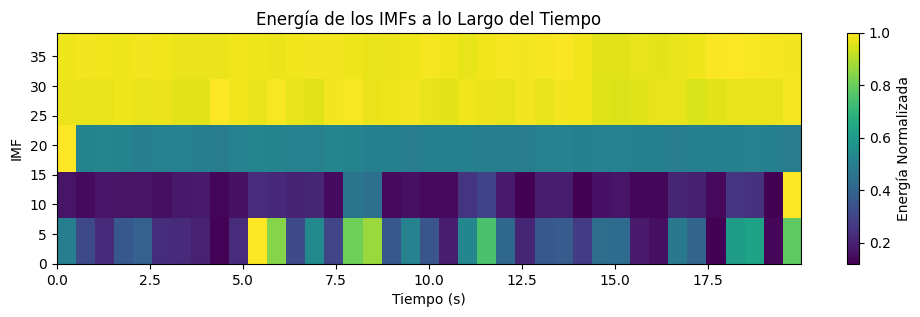

In [36]:
#PERSONA SANA

# Aplicar EMD para obtener los IMFs
imfs_healthy = emd.sift.ensemble_sift(audio_healthy, max_imfs=5)

# Verificar la forma de los IMFs
print("Forma de imfs:", imfs_healthy.shape)

# Graficar la señal original y los IMFs
plt.figure(figsize=(10, 8))
plt.subplot(imfs_healthy.shape[1] + 1, 1, 1)
plt.plot(time_healthy, audio_healthy, 'b')
plt.title("Señal Original")
plt.ylabel("Amplitud")

for i, imf in enumerate(imfs_healthy.T):
    plt.subplot(imfs_healthy.shape[1] + 1, 1, i + 2)
    plt.plot(time_healthy, imf, 'g')
    plt.title(f"IMF {i + 1}")
    plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

# Calcular la energía de los IMFs en ventanas de tiempo
window_size_sec = 1.0  # Ventana de 1 segundo
window_size = int(window_size_sec * sr_healthy)
window_step = window_size // 2  # Superposición del 50%

energy = np.lib.stride_tricks.sliding_window_view(imfs_healthy**2, window_shape=window_size, axis=0)[::window_step, :, :]
energy = np.sum(energy, axis=-1)

# Normalizar la energía
max_energies = np.max(energy, axis=0)
energy = energy / max_energies

# Graficar el mapa de calor de la energía
plt.figure(figsize=(12, 3))
plt.imshow(energy.T, aspect='auto', extent=[time_healthy[0], time_healthy[-1], 0, energy.shape[0]], cmap='viridis')
plt.colorbar(label="Energía Normalizada")
plt.xlabel("Tiempo (s)")
plt.ylabel("IMF")
plt.title("Energía de los IMFs a lo Largo del Tiempo")
plt.show()

In [38]:
# PACIENTE ENFERMO + TOS
audio_path = "./Respiratory_Sound_Database\Respiratory_Sound_Database//audio_and_txt_files//104_1b1_Al_sc_Litt3200.wav"
audio_sick_tos, sr_sick_tos = librosa.load(audio_path, sr=None)  # sr=None para mantener la tasa de muestreo original
time_sick_tos = np.arange(len(audio_sick_tos))/sr_sick_tos

print(f"Duración del audio: {len(audio_sick_tos)/sr_sick_tos} segundos")
print(f"Tasa de muestreo: {sr_sick_tos} Hz")


Duración del audio: 15.856 segundos
Tasa de muestreo: 4000 Hz


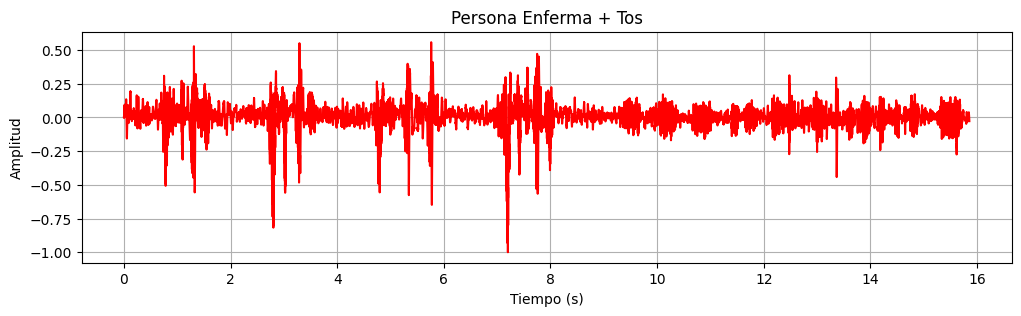

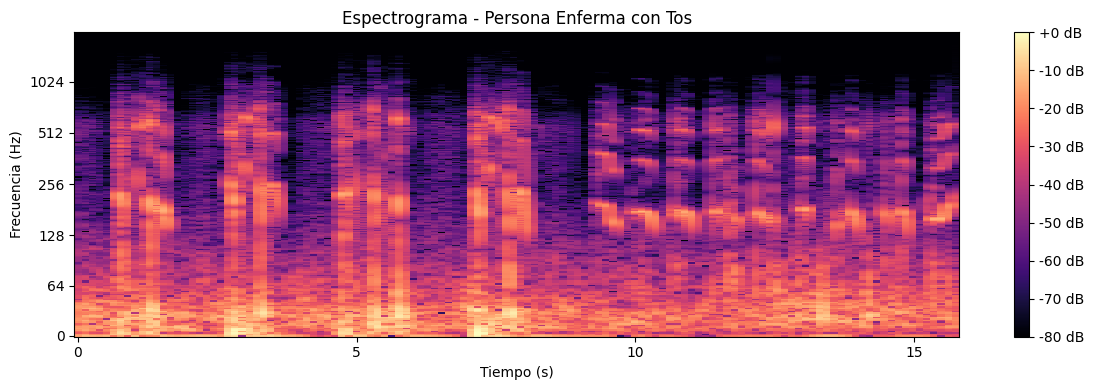

In [24]:
# Forma de onda
plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(audio_sick_tos)) / sr, audio_sick_tos, color='red')
plt.title("Persona Enferma + Tos")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo (s)")
plt.grid()
plt.show()

# Espectrograma
D_sick_tos = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sick_tos)), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(D_sick_tos, sr=sr, x_axis='time', y_axis='log')
plt.title("Espectrograma - Persona Enferma con Tos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

Forma de imfs: (63424, 5)


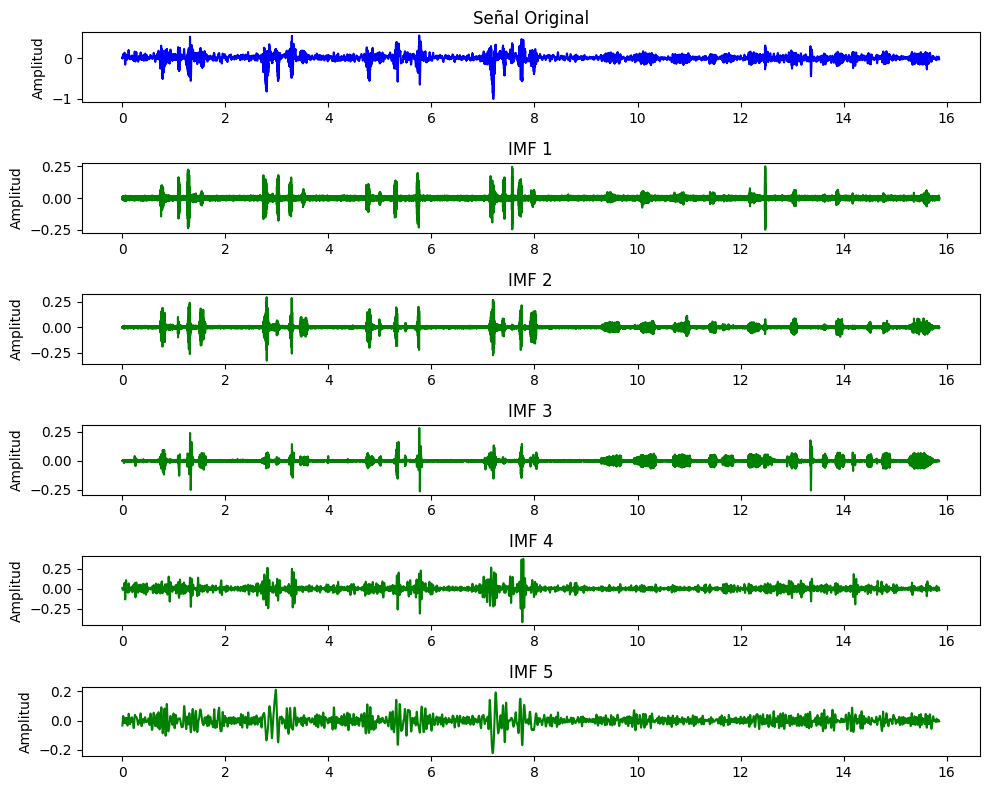

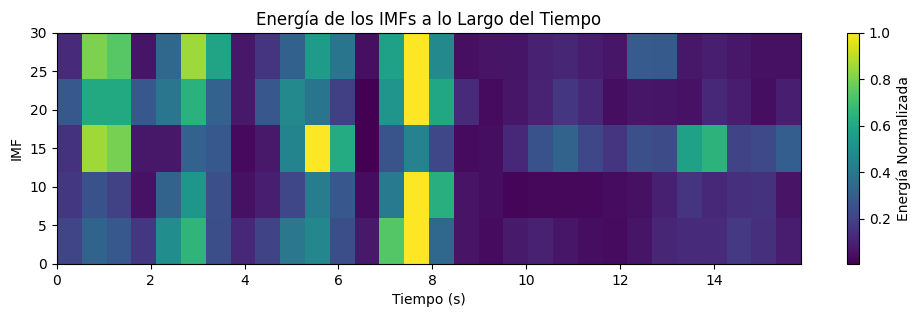

In [39]:
#PERSONA ENFERMA + TOS

# Aplicar EMD para obtener los IMFs
imfs_sick_tos = emd.sift.ensemble_sift(audio_sick_tos, max_imfs=5)

# Verificar la forma de los IMFs
print("Forma de imfs:", imfs_sick_tos.shape)

# Graficar la señal original y los IMFs
plt.figure(figsize=(10, 8))
plt.subplot(imfs_sick_tos.shape[1] + 1, 1, 1)
plt.plot(time_sick_tos, audio_sick_tos, 'b')
plt.title("Señal Original")
plt.ylabel("Amplitud")

for i, imf in enumerate(imfs_sick_tos.T):
    plt.subplot(imfs_sick_tos.shape[1] + 1, 1, i + 2)
    plt.plot(time_sick_tos, imf, 'g')
    plt.title(f"IMF {i + 1}")
    plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

# Calcular la energía de los IMFs en ventanas de tiempo
window_size_sec = 1.0  # Ventana de 1 segundo
window_size = int(window_size_sec * sr_sick_tos)
window_step = window_size // 2  # Superposición del 50%

energy = np.lib.stride_tricks.sliding_window_view(imfs_sick_tos**2, window_shape=window_size, axis=0)[::window_step, :, :]
energy = np.sum(energy, axis=-1)

# Normalizar la energía
max_energies = np.max(energy, axis=0)
energy = energy / max_energies

# Graficar el mapa de calor de la energía
plt.figure(figsize=(12, 3))
plt.imshow(energy.T, aspect='auto', extent=[time_sick_tos[0], time_sick_tos[-1], 0, energy.shape[0]], cmap='viridis')
plt.colorbar(label="Energía Normalizada")
plt.xlabel("Tiempo (s)")
plt.ylabel("IMF")
plt.title("Energía de los IMFs a lo Largo del Tiempo")
plt.show()